# Прогнозирование трафика сайта компании

В работе решается задача прогнозирования временного ряда посещений сайта на основе предоставленной базы трафика. Ключевой критерий качества — соответствие графика автокорреляции прогноза графику автокорреляции исходного сигнала при длине анализа `length = 60`.

Исходный ряд представляет собой ежедневные посещения сайта и содержит выраженную недельную сезонность (период 7 дней), которая обязательно должна быть отражена в автокорреляционной структуре прогноза. Поэтому основная модель обучается напрямую на исходных значениях ряда с архитектурой, способной запомнить сезонные паттерны: две LSTM-сети поверх свёрточного слоя. Для сравнения дополнительно рассматриваются два альтернативных подхода: обучение на простых первых разностях ряда и обучение на сезонных разностях с лагом 7. Это позволяет в численной форме показать, какой способ подготовки данных лучше воспроизводит автокорреляционные свойства исходного сигнала.

## Подготовка

In [1]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Классы-конструкторы моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, LSTM, MaxPooling1D

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировщик
from sklearn.preprocessing import StandardScaler

# Загрузка датасетов из облака google
import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt

# Отрисовка графики в ячейке colab
%matplotlib inline

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

# Фиксация случайных значений для воспроизводимости
import tensorflow as tf
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Загружаем базу трафика с сайта компании
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/traff.csv', None, quiet=True)

'traff.csv'

## Загрузка данных

Файл `traff.csv` имеет нестандартную структуру: отсутствует заголовок, числа записаны с запятой как разделителем разрядов (например, `22,226.00`), а первая колонка содержит дату. Чтение выполняется в несколько этапов: сначала файл просматривается в сыром виде, затем разбирается с явным указанием отсутствия заголовка, после чего числовые столбцы очищаются от запятых-разделителей разрядов и приводятся к типу float. В качестве целевого ряда берётся колонка с наибольшим количеством корректно распознанных числовых значений.

In [4]:
# Просмотр первых строк файла в сыром виде, чтобы понять формат
with open('traff.csv', 'r', encoding='utf-8') as f:
    head = [next(f) for _ in range(5)]
for i, line in enumerate(head):
    print(f'{i}: {line.rstrip()}')

0: 1/1/2017,"22,226.00"
1: 1/2/2017,"29,593.00"
2: 1/3/2017,"31,726.00"
3: 1/4/2017,"32,684.00"
4: 1/5/2017,"31,820.00"


In [5]:
# Чтение файла без заголовка с автоматическим определением разделителя
raw = pd.read_csv('traff.csv', sep=None, engine='python', header=None, dtype=str)
print('Форма таблицы:', raw.shape)
raw.head()

Форма таблицы: (1095, 2)


,0,1
0,1/1/2017,"22,226.00"
1,1/2/2017,"29,593.00"
2,1/3/2017,"31,726.00"
3,1/4/2017,"32,684.00"
4,1/5/2017,"31,820.00"


In [6]:
# Очистка значений: убираем разделители разрядов (запятые в числах вида '22,226.00'),
# пробелы и приводим каждую колонку к числу. Нечисловые значения станут NaN.
def to_number_clean(series):
    s = series.astype(str)
    s = s.str.replace(',', '', regex=False)   # убираем запятые-разделители разрядов
    s = s.str.strip()
    return pd.to_numeric(s, errors='coerce')

cleaned = pd.DataFrame({c: to_number_clean(raw[c]) for c in raw.columns})
print('Доля числовых значений в каждой колонке:')
for c in cleaned.columns:
    valid = cleaned[c].notna().sum()
    total = len(cleaned[c])
    print(f'  колонка {c}: {valid} из {total} ({100 * valid / total:.1f}%)')

Доля числовых значений в каждой колонке:
  колонка 0: 0 из 1095 (0.0%)
  колонка 1: 1095 из 1095 (100.0%)


In [7]:
# Выбор колонки с наибольшей долей числовых значений - это и есть трафик.
# Колонка с датами не парсится как число и отсеивается автоматически.
valid_counts = {c: cleaned[c].notna().sum() for c in cleaned.columns}
target_col = max(valid_counts, key=valid_counts.get)
print(f'Целевая колонка: {target_col!r} ({valid_counts[target_col]} числовых значений)')

# Берём только эту колонку, удаляем строки с NaN (если первая строка была заголовком, она отсеется)
series_raw = cleaned[target_col].dropna().reset_index(drop=True)
series_raw = np.asarray(series_raw.values, dtype=np.float32)

print('Тип:', type(series_raw).__name__)
print('dtype:', series_raw.dtype)
print('Длина ряда:', series_raw.shape[0])
print('Первые значения:', series_raw[:10])

Целевая колонка: 1 (1095 числовых значений)
Тип: ndarray
dtype: float32
Длина ряда: 1095
Первые значения: [22226. 29593. 31726. 32684. 31820. 29354. 29139. 31244. 32690. 31299.]


## Визуализация исходного ряда

Сначала строится график всего ряда, затем приближённый вид одного его участка длиной 1000 точек, чтобы оценить характерную динамику.

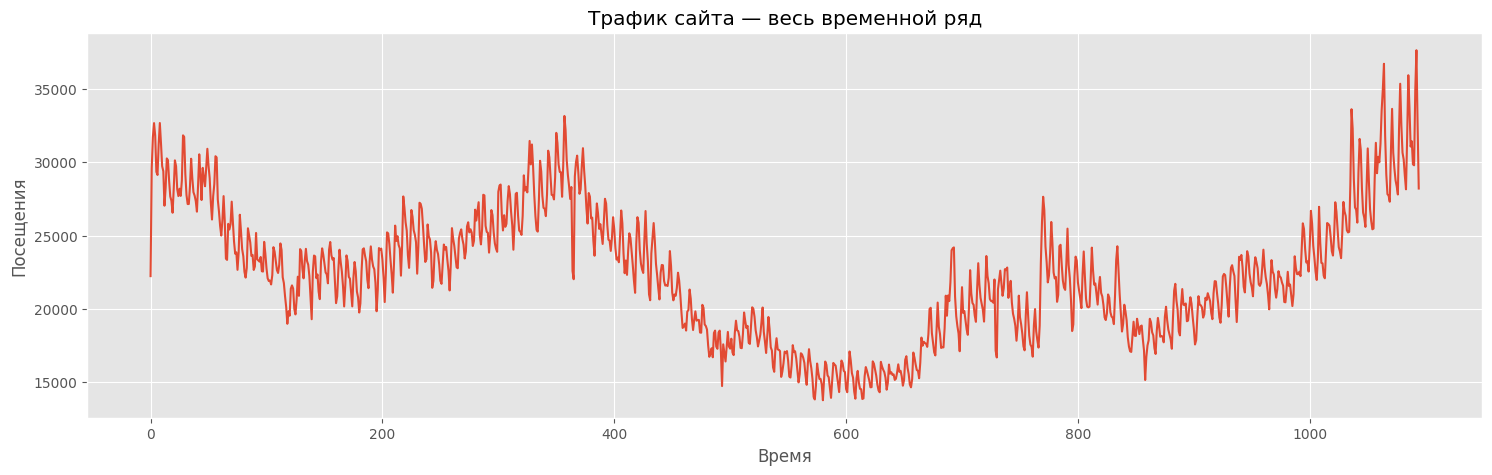

In [8]:
# Весь ряд целиком
plt.figure(figsize=(18, 5))
plt.plot(series_raw)
plt.title('Трафик сайта — весь временной ряд')
plt.xlabel('Время')
plt.ylabel('Посещения')
plt.show()

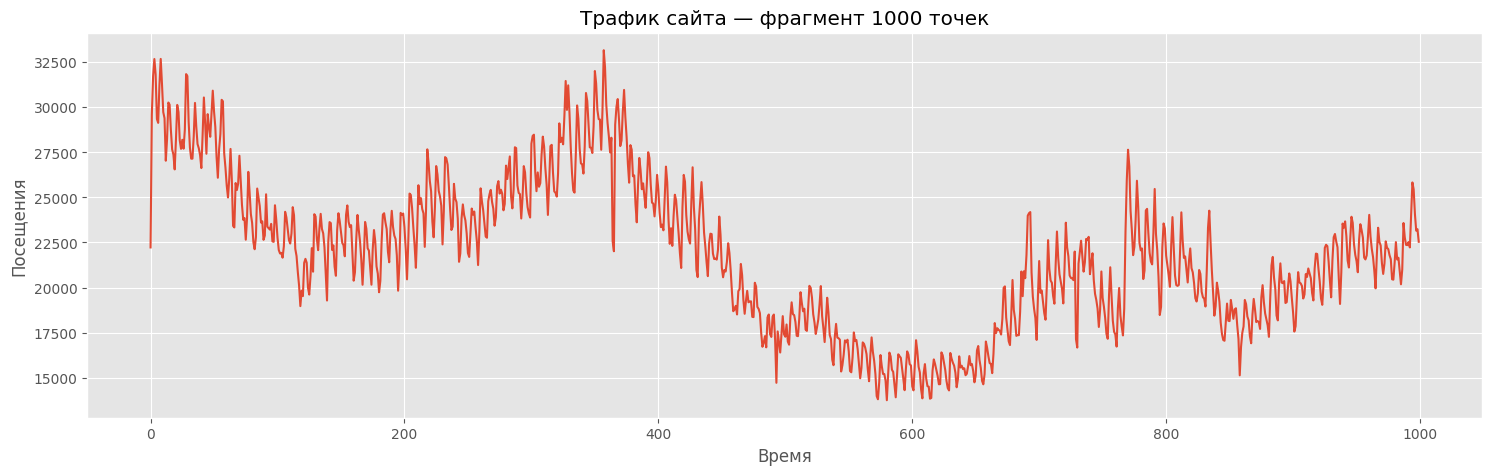

In [9]:
# Фрагмент ряда длиной 1000 точек
start = 0
length_plot = min(1000, series_raw.shape[0])
plt.figure(figsize=(18, 5))
plt.plot(series_raw[start:start + length_plot])
plt.title('Трафик сайта — фрагмент 1000 точек')
plt.xlabel('Время')
plt.ylabel('Посещения')
plt.show()

## Гиперпараметры и подготовка выборок

Длина анализируемой подпоследовательности фиксируется равной 60, как указано в условии. Данные разделяются на обучающую и тестовую части в хронологическом порядке. Между ними оставляется зазор, чтобы исключить пересечение окон.

In [10]:
# Гиперпараметры
SEQ_LEN = 60                              # Длина анализируемой подпоследовательности
BATCH_SIZE = 32                           # Размер батча
TEST_FRACTION = 0.2                       # Доля тестовой части

# Разделение по времени
n_total = series_raw.shape[0]
n_test = max(int(n_total * TEST_FRACTION), SEQ_LEN * 4)
n_train = n_total - n_test - 2 * SEQ_LEN  # с зазором между обучением и тестом

series_train_raw = np.asarray(series_raw[:n_train], dtype=np.float32)
series_test_raw  = np.asarray(series_raw[n_train + 2 * SEQ_LEN:], dtype=np.float32)

print('Train:', series_train_raw.shape, 'Test:', series_test_raw.shape)

Train: (735,) Test: (240,)


### Предварительный анализ автокорреляции ряда

Ежедневный трафик сайтов обычно демонстрирует ярко выраженную недельную сезонность: посетители ведут себя по-разному в будни и выходные. Чтобы убедиться в этом и в дальнейшем правильно подобрать архитектуру модели, заранее строится график автокорреляции обучающей части ряда. Если на лагах 7, 14, 21 присутствуют локальные максимумы — недельная сезонность подтверждена и должна быть отражена в прогнозе.

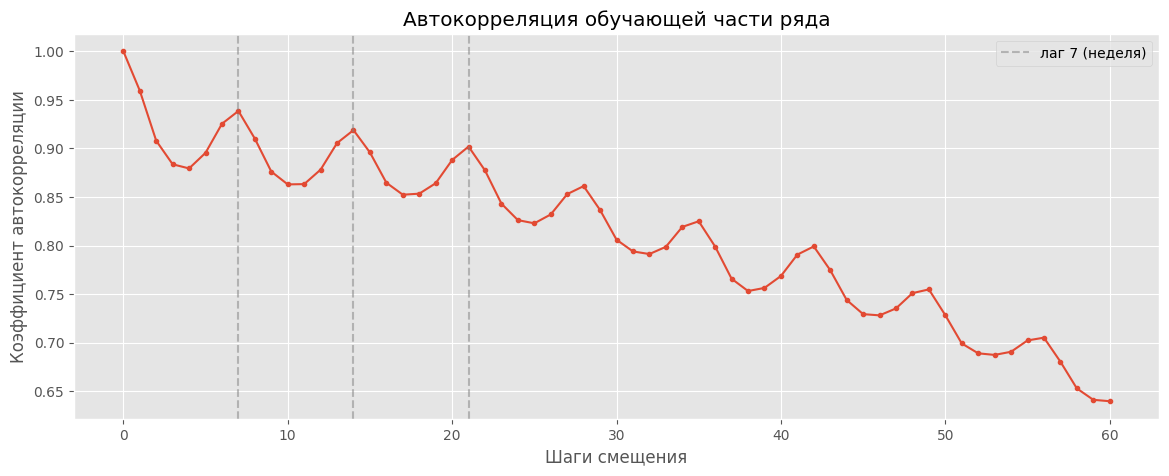

In [11]:
# Вспомогательная функция: коэффициент автокорреляции при заданном смещении
def get_corr_coef(data, back_steps):
    a = np.asarray(data).ravel()
    if back_steps == 0:
        return 1.0
    return np.corrcoef(a[back_steps:], a[:len(a) - back_steps])[0, 1]


def autocorr_curve(series, length):
    return np.array([get_corr_coef(series, s) for s in range(length + 1)])


# График автокорреляции обучающей части
ac_train = autocorr_curve(series_train_raw, 60)
plt.figure(figsize=(14, 5))
plt.plot(ac_train, marker='.')
plt.title('Автокорреляция обучающей части ряда')
plt.xlabel('Шаги смещения')
plt.ylabel('Коэффициент автокорреляции')
plt.axvline(7, color='gray', linestyle='--', alpha=0.5, label='лаг 7 (неделя)')
plt.axvline(14, color='gray', linestyle='--', alpha=0.5)
plt.axvline(21, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Нормализация

Нормировщик настраивается только на обучающей части ряда, затем применяется к обоим участкам.

In [12]:
# Нормализация исходных значений ряда
scaler = StandardScaler()
scaler.fit(series_train_raw.reshape(-1, 1))

x_train_sc = scaler.transform(series_train_raw.reshape(-1, 1)).astype(np.float32)
x_test_sc  = scaler.transform(series_test_raw.reshape(-1, 1)).astype(np.float32)

print('Train sc:', x_train_sc.shape, 'Test sc:', x_test_sc.shape)

Train sc: (735, 1) Test sc: (240, 1)


### Генераторы выборок

Для обучения используется `TimeseriesGenerator`: на вход подаётся окно из 60 предыдущих значений ряда, на выходе ожидается следующее значение. Все генераторы используют один и тот же размер батча — это и подаёт данные сети ленивыми порциями, и удерживает память под контролем при последующем прохождении по тестовой выборке.

In [13]:
# Обучающий генератор
train_gen = TimeseriesGenerator(x_train_sc, x_train_sc,
                                length=SEQ_LEN,
                                stride=1,
                                sampling_rate=1,
                                batch_size=BATCH_SIZE)

# Тестовый генератор
test_gen = TimeseriesGenerator(x_test_sc, x_test_sc,
                               length=SEQ_LEN,
                               stride=1,
                               sampling_rate=1,
                               batch_size=BATCH_SIZE)

print('Батчей в обучающем наборе:', len(train_gen))
print('Батчей в тестовом наборе :', len(test_gen))

Батчей в обучающем наборе: 22
Батчей в тестовом наборе : 6


In [14]:
# Утилита для сбора прогноза и эталона по всему генератору одним проходом.
# Используется после обучения для построения графиков и численной оценки качества.
# Возвращает два numpy-массива одинаковой длины: предсказание и фактические метки.
def collect_predictions(model, gen):
    preds, trues = [], []
    for i in range(len(gen)):
        xb, yb = gen[i]
        preds.append(model.predict(xb, verbose=0))
        trues.append(yb)
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)

### Функция отображения графиков автокорреляции

Помимо уже определённой функции `get_corr_coef`, для удобства сравнения нескольких рядов используется обёртка `show_autocorr`, которая строит кривые автокорреляции на одной координатной плоскости.

In [15]:
# Функция построения графика коэффициентов автокорреляции для одного или нескольких рядов
def show_autocorr(series_dict, steps_max, title=''):
    steps = list(range(0, steps_max + 1))
    plt.figure(figsize=(14, 7))
    for label, series in series_dict.items():
        coefs = [get_corr_coef(series, s) for s in steps]
        plt.plot(steps, coefs, marker='.', label=label)
    plt.xticks(steps[::max(1, len(steps) // 30)])
    plt.title(title)
    plt.xlabel('Шаги смещения')
    plt.ylabel('Коэффициент автокорреляции')
    plt.legend()
    plt.show()

## Основная модель прогнозирования

Архитектура подбиралась с учётом необходимости запомнить сезонные паттерны длиной до недели и более. Свёрточный слой `Conv1D` с шириной ядра 7 (равной недельному периоду) извлекает локальные паттерны, охватывающие целую неделю. Далее идут два слоя LSTM: первый возвращает полную последовательность скрытых состояний, второй сворачивает её в один вектор. Финальный `Dense` выдаёт одно число — прогнозное значение посещений для следующего дня. Регуляризация через `Dropout` снижает риск переобучения, что важно при ограниченном размере датасета.

In [16]:
# Архитектура
model = Sequential([
    Conv1D(64, kernel_size=7, padding='causal', activation='relu',
           input_shape=(SEQ_LEN, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(loss='mse', optimizer=Adam(learning_rate=1e-3))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 60, 64)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,673 (268.25 KB)

 Trainable params: 68,673 (268.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Обучение
history = model.fit(train_gen,
                    epochs=80,
                    validation_data=test_gen,
                    verbose=1)

Epoch 1/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.4201 - val_loss: 0.2891
Epoch 2/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1779 - val_loss: 0.3493
Epoch 3/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1599 - val_loss: 0.2315
Epoch 4/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1467 - val_loss: 0.3354
Epoch 5/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1488 - val_loss: 0.3278
Epoch 6/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1525 - val_loss: 0.2304
Epoch 7/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1584 - val_loss: 0.3838
Epoch 8/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1546 - val_loss: 0.3682
Epoch 9/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1488 - val_loss: 0.3057
Epoch 10/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1627 - val_loss: 0.2658
Epoch 11/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1893 - val_loss: 0.2319
Epoch 12/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1

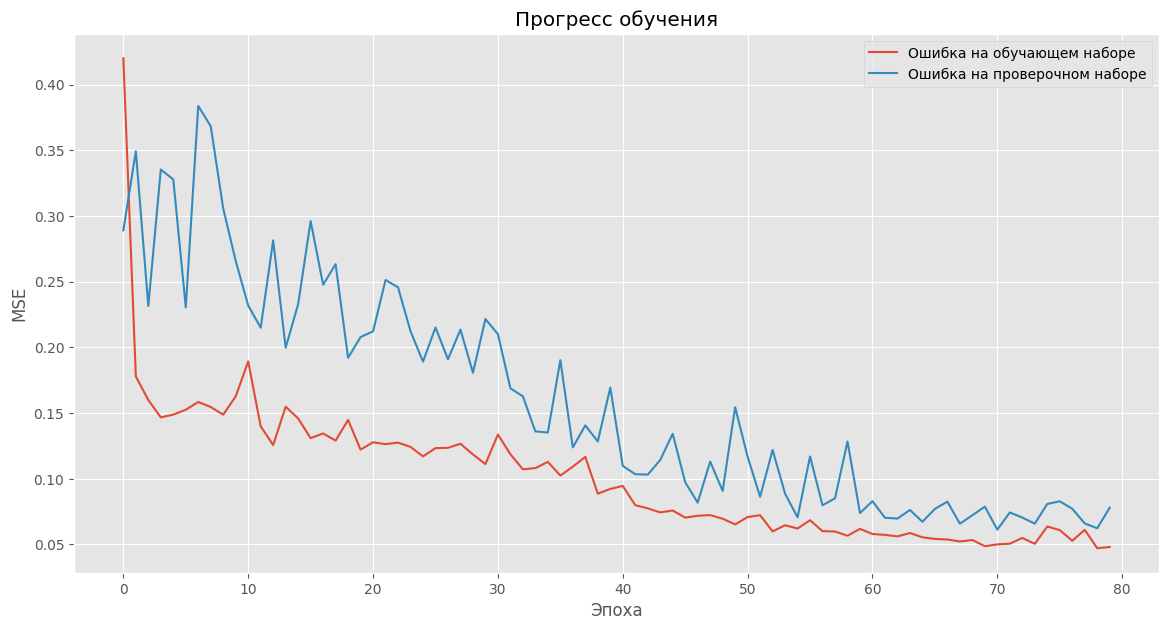

In [18]:
# График ошибки обучения
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Ошибка на обучающем наборе')
plt.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
plt.title('Прогресс обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.show()

## Прогноз и оценка качества основной модели

Сеть выдаёт нормированные значения посещений. Достаточно одной обратной операции — денормализации, после чего полученные значения сопоставляются с эталоном.

In [19]:
# Прогноз на тестовой выборке - сбор батчами
y_pred_sc, y_true_sc = collect_predictions(model, test_gen)

# Денормализация
y_pred_values = scaler.inverse_transform(y_pred_sc).ravel()
y_true_values = scaler.inverse_transform(y_true_sc).ravel()

print('Эталон :', y_true_values.shape)
print('Прогноз:', y_pred_values.shape)

Эталон : (180,)
Прогноз: (180,)


### Сравнение прогноза с эталоном во времени

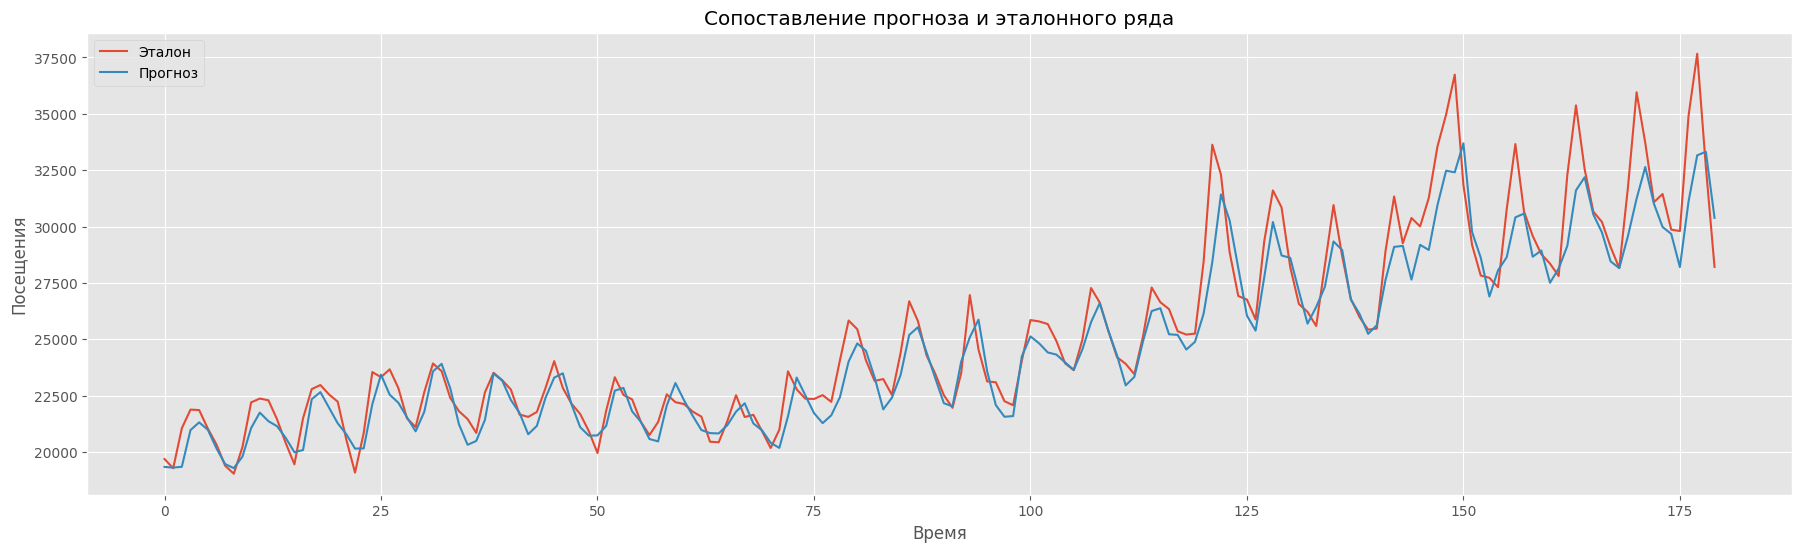

In [20]:
# Фрагмент сравнения по времени
start = 0
length_show = min(500, y_true_values.shape[0])

plt.figure(figsize=(22, 6))
plt.plot(y_true_values[start:start + length_show], label='Эталон')
plt.plot(y_pred_values[start:start + length_show], label='Прогноз')
plt.title('Сопоставление прогноза и эталонного ряда')
plt.xlabel('Время')
plt.ylabel('Посещения')
plt.legend()
plt.show()

### Графики автокорреляции для length = 60

Главный критерий качества по условию задачи. Чем ближе кривая автокорреляции прогноза к кривой автокорреляции эталона, тем лучше модель воспроизводит структуру сигнала.

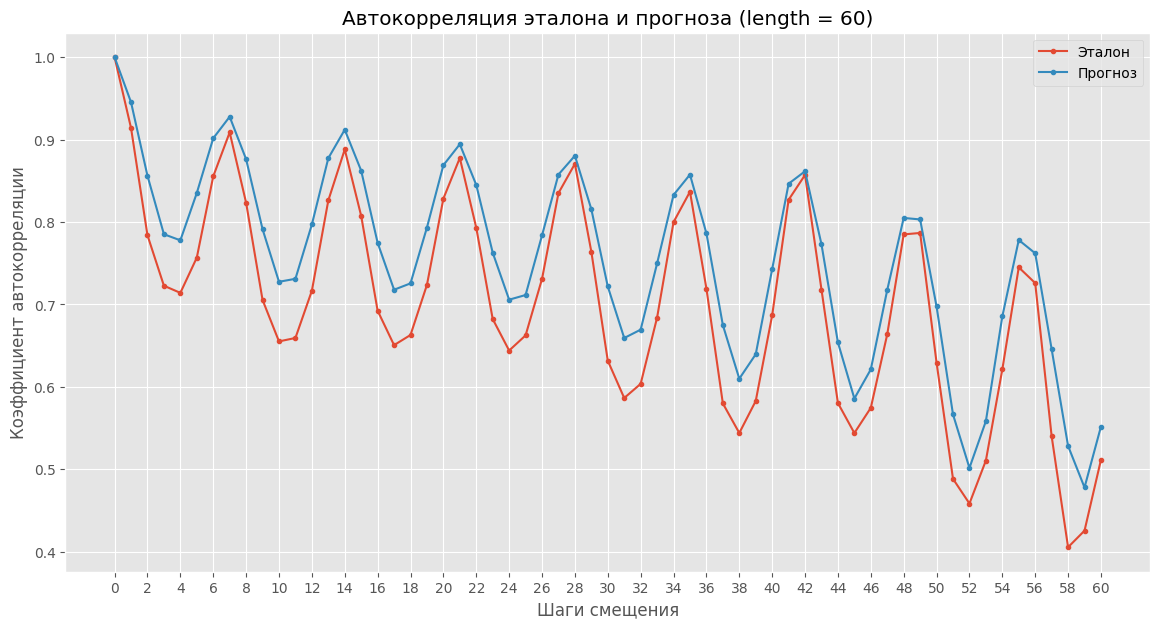

In [21]:
# Длина анализа автокорреляции согласно условию задания
LENGTH = 60

# Совмещённый график автокорреляций
show_autocorr({'Эталон': y_true_values,
               'Прогноз': y_pred_values},
              steps_max=LENGTH,
              title=f'Автокорреляция эталона и прогноза (length = {LENGTH})')

In [22]:
# Численная оценка соответствия графиков автокорреляции:
# среднее абсолютное отклонение коэффициентов автокорреляции по всем шагам смещения от 0 до LENGTH
ac_true = autocorr_curve(y_true_values, LENGTH)
ac_pred = autocorr_curve(y_pred_values, LENGTH)

mae_ac = np.mean(np.abs(ac_true - ac_pred))
max_ac = np.max(np.abs(ac_true - ac_pred))

print(f'Среднее отклонение кривых автокорреляции: {mae_ac:.4f}')
print(f'Максимальное отклонение по шагам:         {max_ac:.4f}')

Среднее отклонение кривых автокорреляции: 0.0541
Максимальное отклонение по шагам:         0.1229


## Контрольное сравнение: альтернативные способы подготовки данных

Для проверки выбора подхода обучаются две альтернативные модели той же архитектуры, отличающиеся только способом подготовки входного сигнала:

1. **Первая разность** — сеть прогнозирует приращение `x[n] - x[n-1]`, исходный ряд восстанавливается накопительным суммированием. Этот приём убирает линейный тренд, но плохо подходит для рядов с сильной периодичностью.
2. **Сезонная разность с лагом 7** — сеть прогнозирует `x[n] - x[n-7]`, и для восстановления исходного значения к прогнозу добавляется реальное значение неделю назад. Этот подход напрямую учитывает недельную сезонность ряда.

После обучения для каждой модели строится автокорреляционная кривая, и все три прогноза сравниваются с эталоном — численно по среднему и максимальному отклонению коэффициентов автокорреляции.

### Контрольная модель 1 — первая разность

In [23]:
# Подготовка данных на первой разности
series_train_diff = np.diff(series_train_raw)
series_test_diff  = np.diff(series_test_raw)

scaler_d1 = StandardScaler()
scaler_d1.fit(series_train_diff.reshape(-1, 1))
x_train_d1 = scaler_d1.transform(series_train_diff.reshape(-1, 1)).astype(np.float32)
x_test_d1  = scaler_d1.transform(series_test_diff.reshape(-1, 1)).astype(np.float32)

train_gen_d1 = TimeseriesGenerator(x_train_d1, x_train_d1,
                                   length=SEQ_LEN, stride=1, sampling_rate=1,
                                   batch_size=BATCH_SIZE)
test_gen_d1  = TimeseriesGenerator(x_test_d1, x_test_d1,
                                   length=SEQ_LEN, stride=1, sampling_rate=1,
                                   batch_size=BATCH_SIZE)

In [24]:
# Та же архитектура
model_d1 = Sequential([
    Conv1D(64, kernel_size=7, padding='causal', activation='relu',
           input_shape=(SEQ_LEN, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model_d1.compile(loss='mse', optimizer=Adam(learning_rate=1e-3))

history_d1 = model_d1.fit(train_gen_d1,
                          epochs=80,
                          validation_data=test_gen_d1,
                          verbose=1)

Epoch 1/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.9249 - val_loss: 1.6887
Epoch 2/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8519 - val_loss: 1.3634
Epoch 3/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7598 - val_loss: 1.1049
Epoch 4/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6984 - val_loss: 1.0608
Epoch 5/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6572 - val_loss: 1.0651
Epoch 6/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6358 - val_loss: 0.9497
Epoch 7/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6187 - val_loss: 0.9113
Epoch 8/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5820 - val_loss: 0.8661
Epoch 9/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5811 - val_loss: 0.7732
Epoch 10/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5648 - val_loss: 0.8226
Epoch 11/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.5449 - val_loss: 0.7477
Epoch 12/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5

In [25]:
# Прогноз приращений и восстановление исходного ряда через cumsum
y_pred_d1_sc, y_true_d1_sc = collect_predictions(model_d1, test_gen_d1)
y_pred_d1_diff = scaler_d1.inverse_transform(y_pred_d1_sc).ravel()
y_true_d1_diff = scaler_d1.inverse_transform(y_true_d1_sc).ravel()

# Восстановление исходного ряда из приращений
# Смещение: длина пропущена из-за np.diff (-1) и из-за окна (SEQ_LEN)
offset = SEQ_LEN + 1
y_true_d1_values = series_test_raw[offset: offset + y_true_d1_diff.shape[0]]
start_value = series_test_raw[offset - 1]
y_pred_d1_values = start_value + np.cumsum(y_pred_d1_diff)

print('Эталон :', y_true_d1_values.shape, 'Прогноз:', y_pred_d1_values.shape)

Эталон : (179,) Прогноз: (179,)


### Контрольная модель 2 — сезонная разность с лагом 7

In [26]:
# Подготовка данных на сезонной разности (lag = 7)
LAG = 7
series_train_sd = series_train_raw[LAG:] - series_train_raw[:-LAG]
series_test_sd  = series_test_raw[LAG:]  - series_test_raw[:-LAG]

scaler_sd = StandardScaler()
scaler_sd.fit(series_train_sd.reshape(-1, 1))
x_train_sd = scaler_sd.transform(series_train_sd.reshape(-1, 1)).astype(np.float32)
x_test_sd  = scaler_sd.transform(series_test_sd.reshape(-1, 1)).astype(np.float32)

train_gen_sd = TimeseriesGenerator(x_train_sd, x_train_sd,
                                   length=SEQ_LEN, stride=1, sampling_rate=1,
                                   batch_size=BATCH_SIZE)
test_gen_sd  = TimeseriesGenerator(x_test_sd, x_test_sd,
                                   length=SEQ_LEN, stride=1, sampling_rate=1,
                                   batch_size=BATCH_SIZE)

In [27]:
# Та же архитектура
model_sd = Sequential([
    Conv1D(64, kernel_size=7, padding='causal', activation='relu',
           input_shape=(SEQ_LEN, 1)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model_sd.compile(loss='mse', optimizer=Adam(learning_rate=1e-3))

history_sd = model_sd.fit(train_gen_sd,
                          epochs=80,
                          validation_data=test_gen_sd,
                          verbose=1)

Epoch 1/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.9447 - val_loss: 1.2410
Epoch 2/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9133 - val_loss: 1.1824
Epoch 3/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8531 - val_loss: 1.1508
Epoch 4/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8164 - val_loss: 1.0404
Epoch 5/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7579 - val_loss: 0.9341
Epoch 6/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7081 - val_loss: 0.8852
Epoch 7/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6637 - val_loss: 0.7743
Epoch 8/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6290 - val_loss: 0.7958
Epoch 9/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6021 - val_loss: 0.7310
Epoch 10/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5933 - val_loss: 0.6824
Epoch 11/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5605 - val_loss: 0.5852
Epoch 12/80
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5

In [28]:
# Прогноз сезонных приращений и восстановление: y[n] = y[n-7] + pred
y_pred_sd_sc, y_true_sd_sc = collect_predictions(model_sd, test_gen_sd)
y_pred_sd_diff = scaler_sd.inverse_transform(y_pred_sd_sc).ravel()

# Целевая точка t соответствует точке (LAG + SEQ_LEN + i) в исходном тестовом ряду
offset = LAG + SEQ_LEN
y_true_sd_values = series_test_raw[offset: offset + y_pred_sd_diff.shape[0]]

# Для восстановления нужно реальное значение неделю назад: series_test_raw[offset - LAG + i]
seven_days_ago = series_test_raw[offset - LAG: offset - LAG + y_pred_sd_diff.shape[0]]
y_pred_sd_values = seven_days_ago + y_pred_sd_diff

print('Эталон :', y_true_sd_values.shape, 'Прогноз:', y_pred_sd_values.shape)

Эталон : (173,) Прогноз: (173,)


### Сравнение всех трёх подходов

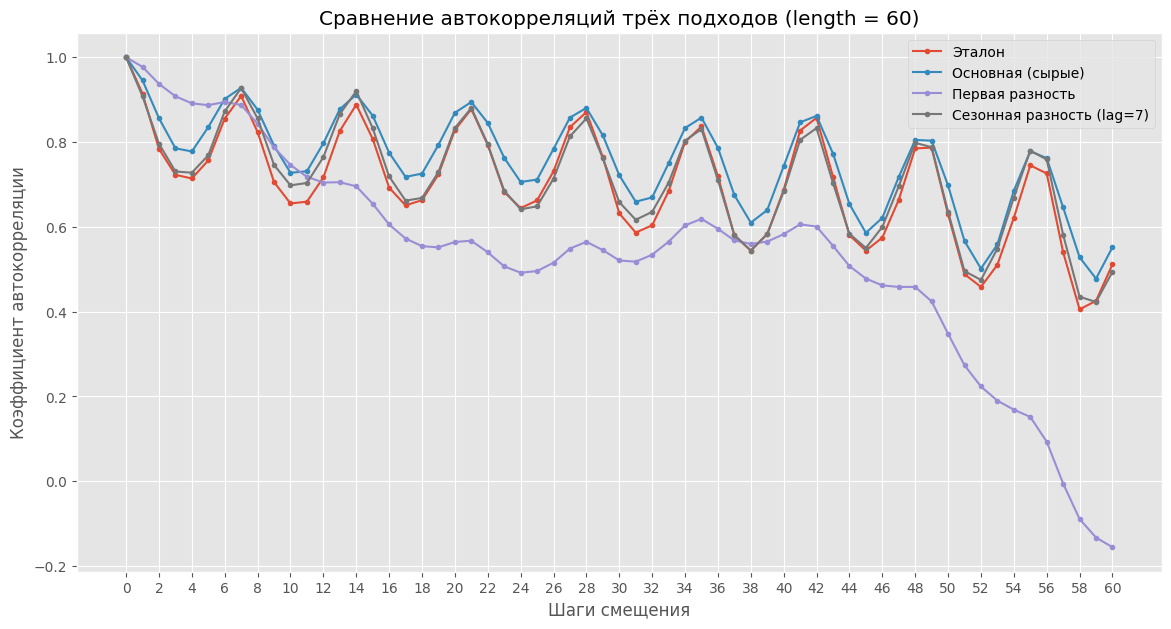

In [29]:
# Сравнение автокорреляций четырёх кривых: эталон и три прогноза.
# Эталон берётся для основной модели — остальные эталоны такие же по форме автокорреляции,
# так как это один и тот же тестовый ряд (отличаются только по числу точек из-за смещений).
show_autocorr({'Эталон': y_true_values,
               'Основная (сырые)': y_pred_values,
               'Первая разность': y_pred_d1_values,
               'Сезонная разность (lag=7)': y_pred_sd_values},
              steps_max=LENGTH,
              title=f'Сравнение автокорреляций трёх подходов (length = {LENGTH})')

In [30]:
# Численное сопоставление: для каждого прогноза эталон совпадает по форме,
# но определён на своём срезе. Используем соответствующий y_true для каждой модели.
ac_main = autocorr_curve(y_pred_values,     LENGTH)
ac_d1   = autocorr_curve(y_pred_d1_values,  LENGTH)
ac_sd   = autocorr_curve(y_pred_sd_values,  LENGTH)

ac_true_main = autocorr_curve(y_true_values,    LENGTH)
ac_true_d1   = autocorr_curve(y_true_d1_values, LENGTH)
ac_true_sd   = autocorr_curve(y_true_sd_values, LENGTH)

def report(name, ac_pred, ac_ref):
    mae = np.mean(np.abs(ac_ref - ac_pred))
    mx  = np.max (np.abs(ac_ref - ac_pred))
    return mae, mx

mae_main, max_main = report('Основная',         ac_main, ac_true_main)
mae_d1,   max_d1   = report('Первая разность',  ac_d1,   ac_true_d1)
mae_sd,   max_sd   = report('Сезонная разность',ac_sd,   ac_true_sd)

print('                              mean |Δ|   max |Δ|')
print(f'Основная (сырые значения)     {mae_main:8.4f}   {max_main:.4f}')
print(f'Первая разность               {mae_d1:8.4f}   {max_d1:.4f}')
print(f'Сезонная разность (lag=7)     {mae_sd:8.4f}   {max_sd:.4f}')

                              mean |Δ|   max |Δ|
Основная (сырые значения)       0.0541   0.1229
Первая разность                 0.1969   0.6592
Сезонная разность (lag=7)       0.0287   0.0764
